In [32]:
import pandas as pd

In [33]:

from sklearn.preprocessing import LabelEncoder

In [34]:
df= pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Counter survey project\step-counter-survey.csv')
df.head()

,name,listed_in,ratings_count,rating_average,widget_per_description,reads_health_per_description,last_updated,in_app_purchases,prices_listed,lock_screen_per_description,kind,app_store_id
0,StepsApp Pedometer,simple; free,291037,4.8,yes,yes,Aug 2026,yes,$0.99 – $19.99,yes,NaN,1037595083
1,Pedometer++,simple; free,180123,4.8,yes,yes,May 2026,yes,$1.99 – $39.99,yes,NaN,712286167
2,Pedometer α,simple; free,167598,4.9,no,no,Aug 2026,none,NaN,no,NaN,1027151285
3,Steps — Activity Tracker,simple; free,131721,4.8,yes,yes,Aug 2026,yes,$3.99,yes,NaN,708359518
4,Pikmin Bloom,cute,66956,4.8,no,NaN,Aug 2026,NaN,NaN,no,walking game,1556357398


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          18 non-null     str    
 1   listed_in                     18 non-null     str    
 2   ratings_count                 18 non-null     int64  
 3   rating_average                17 non-null     float64
 4   widget_per_description        18 non-null     str    
 5   reads_health_per_description  9 non-null      str    
 6   last_updated                  18 non-null     str    
 7   in_app_purchases              13 non-null     str    
 8   prices_listed                 9 non-null      str    
 9   lock_screen_per_description   18 non-null     str    
 10  kind                          9 non-null      str    
 11  app_store_id                  18 non-null     int64  
dtypes: float64(1), int64(2), str(9)
memory usage: 2.8 KB


In [36]:
df.isnull().sum()

name                            0
listed_in                       0
ratings_count                   0
rating_average                  1
widget_per_description          0
reads_health_per_description    9
last_updated                    0
in_app_purchases                5
prices_listed                   9
lock_screen_per_description     0
kind                            9
app_store_id                    0
dtype: int64

In [37]:
df['rating_average']= df['rating_average'].fillna(df['rating_average'].median())
df['in_app_purchases']= df['in_app_purchases'].fillna(df['in_app_purchases'].mode()[0])
df['kind']= df['kind'].fillna(df['kind'].mode()[0])

In [38]:
df.drop(columns=['app_store_id','reads_health_per_description','prices_listed','name'], inplace=True)
df

,listed_in,ratings_count,rating_average,widget_per_description,last_updated,in_app_purchases,lock_screen_per_description,kind
0,simple; free,291037,4.8,yes,Aug 2026,yes,yes,step counter
1,simple; free,180123,4.8,yes,May 2026,yes,yes,step counter
2,simple; free,167598,4.9,no,Aug 2026,none,no,step counter
3,simple; free,131721,4.8,yes,Aug 2026,yes,yes,step counter
4,cute,66956,4.8,no,Aug 2026,yes,no,walking game
5,simple; free,32586,4.5,yes,Mar 2026,yes,no,step counter
6,cute; free,8008,4.5,no,Aug 2026,yes,no,walking game
7,simple; free,5309,4.7,yes,Jan 2026,none,yes,step counter
8,cute; free,1267,4.2,yes,Aug 2025,yes,no,counter + virtual dog
9,cute,500,4.6,yes,Aug 2026,yes,no,fitness streaks + pet


In [39]:
df.dtypes

listed_in                          str
ratings_count                    int64
rating_average                 float64
widget_per_description             str
last_updated                       str
in_app_purchases                   str
lock_screen_per_description        str
kind                               str
dtype: object

In [63]:
features = ['listed_in','lock_screen_per_description','in_app_purchases','kind']    

In [41]:
df['listed_in'].unique()

<ArrowStringArray>
['simple; free', 'cute', 'cute; free', 'simple']
Length: 4, dtype: str

In [42]:
df['lock_screen_per_description'].unique()

<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

In [43]:
df['in_app_purchases'].unique()

<ArrowStringArray>
['yes', 'none']
Length: 2, dtype: str

In [64]:
df['kind'].unique()

<ArrowStringArray>
[                 'step counter',                  'walking game',
         'counter + virtual dog',         'fitness streaks + pet',
           'habit tracker + pet', 'counter + collectable animals',
             'counter + hamster']
Length: 7, dtype: str

In [65]:
encoder = dict()
for  feature in features:
    if df[feature].dtype == 'str':
        encoder[feature]= LabelEncoder()
        df[feature] = encoder[feature].fit_transform(df[feature])

In [66]:
df[features].dtypes

listed_in                      int64
lock_screen_per_description    int64
in_app_purchases               int64
kind                           int64
dtype: object

In [67]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
df.dtypes

listed_in                        int64
ratings_count                    int64
rating_average                 float64
widget_per_description           int64
last_updated                     int64
in_app_purchases                 int64
lock_screen_per_description      int64
kind                             int64
dtype: object

In [69]:
df.corr(numeric_only=True)

,listed_in,ratings_count,rating_average,widget_per_description,last_updated,in_app_purchases,lock_screen_per_description,kind
listed_in,1.000000,0.530127,0.261749,0.342997,0.049759,-0.129641,0.377297,0.339679
ratings_count,0.530127,1.000000,0.296709,0.074154,-0.128049,0.038164,0.443554,0.291113
rating_average,0.261749,0.296709,1.000000,-0.072334,-0.107062,-0.136698,0.180834,0.020092
widget_per_description,0.342997,0.074154,-0.072334,1.000000,0.215645,0.188982,0.500000,-0.096617
last_updated,0.049759,-0.128049,-0.107062,0.215645,1.000000,-0.103735,0.254853,0.101334
in_app_purchases,-0.129641,0.038164,-0.136698,0.188982,-0.103735,1.000000,0.094491,0.091295
lock_screen_per_description,0.377297,0.443554,0.180834,0.500000,0.254853,0.094491,1.000000,0.241543
kind,0.339679,0.291113,0.020092,-0.096617,0.101334,0.091295,0.241543,1.000000


<Axes: >

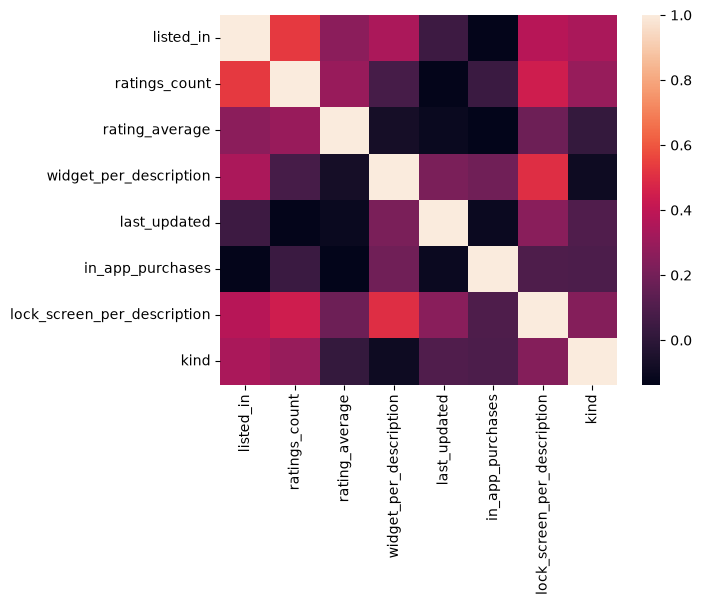

In [70]:
sns.heatmap(df.corr(numeric_only=True))

In [71]:
cat_values=['widget_per_description','last_updated']

In [72]:
encoder = dict()
for  cat in cat_values:
    if df[cat].dtype == 'str':
        encoder[cat]= LabelEncoder()
        df[cat] = encoder[cat].fit_transform(df[cat])

In [73]:
df.head()

,listed_in,ratings_count,rating_average,widget_per_description,last_updated,in_app_purchases,lock_screen_per_description,kind
0,3,291037,4.8,1,1,1,1,5
1,3,180123,4.8,1,6,1,1,5
2,3,167598,4.9,0,1,0,0,5
3,3,131721,4.8,1,1,1,1,5
4,0,66956,4.8,0,1,1,0,6


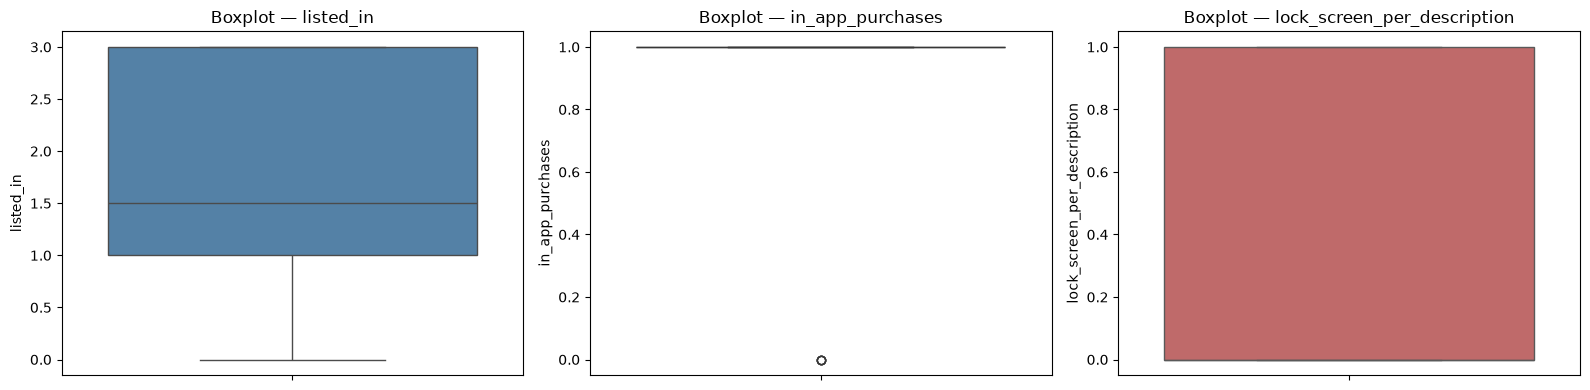

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ["listed_in", "in_app_purchases", "lock_screen_per_description"],
                           ["steelblue", "seagreen", "indianred"]):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f"Boxplot — {col}")
plt.tight_layout()
plt.show()


In [75]:
from sklearn.model_selection import train_test_split
x = df[features]
y = df['ratings_count']

In [76]:
df['ratings_count'].unique()

array([291037, 180123, 167598, 131721,  66956,  32586,   8008,   5309,
         1267,    500,    239,    131,    117,     70,     32,     23,
            2,      0])

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [79]:

from sklearn.linear_model import LogisticRegression

In [80]:
model =LogisticRegression()
model.fit(x,y)
model.score(x,y)

0.7222222222222222

In [81]:
import joblib
import os



project_dir = r"C:\Users\user\OneDrive\Desktop\Counter survey project"


joblib.dump(model, os.path.join(project_dir, 'model.pkl'))
joblib.dump(encoder, os.path.join(project_dir, 'encoder.pkl'))
joblib.dump(features, os.path.join(project_dir, 'features.pkl'))


['C:\\Users\\user\\OneDrive\\Desktop\\Counter survey project\\features.pkl']

In [82]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(features,'features.pkl')

['features.pkl']

In [83]:
df.dtypes

listed_in                        int64
ratings_count                    int64
rating_average                 float64
widget_per_description           int64
last_updated                     int64
in_app_purchases                 int64
lock_screen_per_description      int64
kind                             int64
dtype: object